# Projectile landing optimization

- Optimize the launch speed so the ball lands near the target.
- Concept: [Gradient descent](02-1_gradient_descent_concept.ipynb)


## Decision variable and objective

- The decision variable is horizontal launch speed. The target is 10 m from the release point.
- All candidates use the same release height and neglect air resistance, so flight time is fixed.

> Landing distance = launch speed × flight time

- The cost is proportional to the squared landing error. It forms a convex, U-shaped curve as a function of launch speed.
- The minimum corresponds to a direct hit. A different launch angle or air resistance changes the relationship between speed and landing position.


## Projectile motion and gradient descent

- The gray ball uses the initial speed; the teal ball uses the current speed. Both start together from the same height.
- The lower plot shows launch speed versus cost. The teal point supplies the speed used by the teal ball.
- Past points and arrows show the actual GD updates. With a suitable step size, the point moves toward lower cost as the landing position approaches the target.
- An excessive step size can overshoot the minimum and increase the cost.
- After each flight, the next iteration updates both the launch speed and the point on the cost curve.


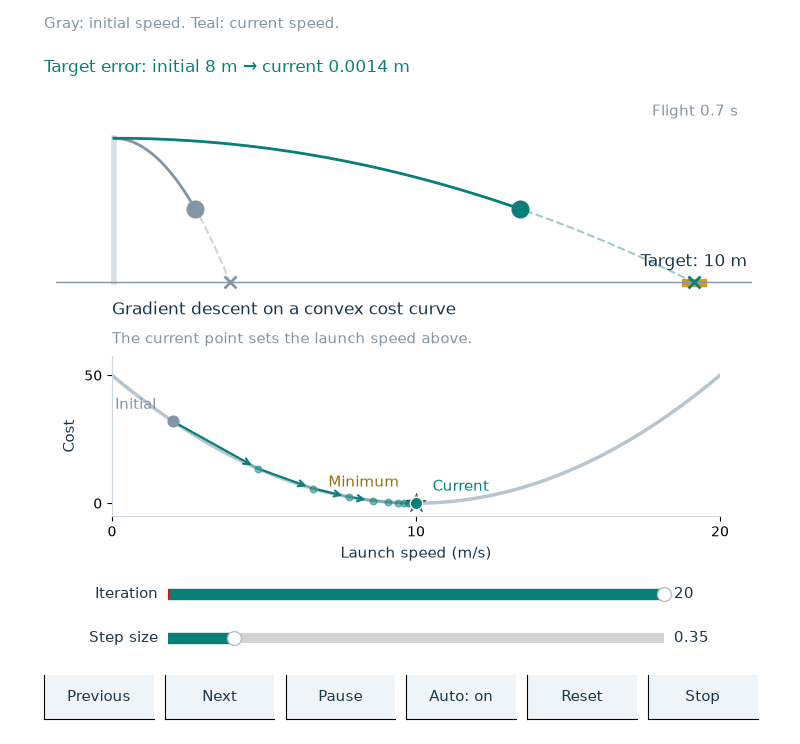

In [1]:
import os
import sys
import time
import base64
from pathlib import Path
from tempfile import gettempdir
import numpy as np
import matplotlib

STATIC = os.environ.get('OPTIMIZATION_STATIC') == '1'
BROWSER = sys.platform == 'emscripten'
INLINE_HTML = bool(globals().pop('_optimization_inline_html', False))
if not STATIC and not BROWSER and not INLINE_HTML:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, 'kernel', None) is not None:
        shell.run_line_magic('matplotlib', 'widget')

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle, Circle

# A subset of DejaVu Sans is bundled for consistent offline rendering.
FONT_DATA = '...'
_font_path = Path(gettempdir()) / 'optimization-lecture-font.ttf'
_font_bytes = base64.b64decode(FONT_DATA)
if not _font_path.exists() or _font_path.read_bytes() != _font_bytes:
    _font_path.write_bytes(_font_bytes)
font_manager.fontManager.addfont(str(_font_path))
_font_name = font_manager.FontProperties(fname=str(_font_path)).get_name()
NAVY, TEAL, GRAY = '#19354c', '#087f79', '#8495a5'
ORANGE, GOLD, RED = '#c56813', '#d39c20', '#bc3b50'
PALE = '#eef4f7'
plt.rcParams.update({
    'font.family': _font_name, 'font.size': 11, 'axes.titlesize': 12,
    'axes.titleweight': 'normal', 'axes.unicode_minus': False,
    'text.color': NAVY, 'axes.labelcolor': NAVY, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'figure.dpi': 100,
})


class LiveView:
    """A motion comparison, one progress curve, and a small set of controls."""

    def __init__(self, subtitle, duration, last_stage, stage_label='Iteration', step_size=False):
        self.figure = plt.figure(figsize=(8, 6.6))
        self.figure.text(.055, .895, subtitle, fontsize=11, color=GRAY)
        self.status = self.figure.text(.055, .840, '', fontsize=12, color=TEAL)
        self.scene = self.figure.add_axes([.07, .465, .87, .34])
        self.progress = self.figure.add_axes([.12, .268, .79, .12])
        self.controls, self.state = {}, {}
        self.duration, self.elapsed = float(duration), 0.
        self.playing, self.automatic, self.running = True, True, False
        self.timer = None
        self.last_tick = time.monotonic()
        self.render = lambda t: None
        self.redraw = lambda: None
        self.last_stage = int(last_stage)
        self.stage_label = stage_label
        self.figure.canvas.mpl_connect('close_event', lambda event: self.stop())
        self.add_slider('stage', stage_label, 0, last_stage, 0, 1, [.21, .175, .62, .025], '%0.0f')
        if step_size:
            self.add_slider('alpha', 'Step size', .05, 2.3, .35, .05, [.21, .120, .62, .025], '%0.2f')
        actions = [('back', 'Previous', lambda _: self.manual_step(-1)),
                   ('next', 'Next', lambda _: self.manual_step(1)),
                   ('play', 'Pause', self.toggle_play),
                   ('auto', 'Auto: on', self.toggle_auto),
                   ('reset', 'Reset', lambda _: self.reset_all()),
                   ('stop', 'Stop', lambda _: self.stop())]
        for i, (name, label, callback) in enumerate(actions):
            button = Button(self.figure.add_axes([.055 + .151*i, .031, .137, .055]), label,
                            color=PALE, hovercolor='#d4e8e4')
            button.label.set_fontsize(10.5)
            button.on_clicked(callback)
            self.controls[name] = button
        self.controls['stage'].on_changed(self.choose_stage)
        if step_size:
            self.controls['alpha'].on_changed(self.change_step_size)
        self.figure._live_view = self

    def compact_header(self):
        width, height = self.figure.get_size_inches()
        new_height = height - .56
        scale = height / new_height
        for ax in self.figure.axes:
            x, y, w, h = ax.get_position().bounds
            ax.set_position([x, y*scale, w, h*scale])
        for text in self.figure.texts:
            x, y = text.get_position()
            text.set_position((x, y*scale))
        self.figure.set_size_inches(width, new_height)

    def add_slider(self, name, label, low, high, initial, step, rect, valfmt):
        slider = Slider(self.figure.add_axes(rect), label, low, high, valinit=initial,
                        valstep=step, valfmt=valfmt, color=TEAL)
        slider.label.set_fontsize(11)
        slider.valtext.set_fontsize(11)
        self.controls[name] = slider

    def values(self, **values):
        for name, value in values.items():
            slider = self.controls[name]
            old_events, old_draw = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = old_events, old_draw

    def sync(self):
        self.controls['play'].label.set_text('Pause' if self.playing else 'Play')
        self.controls['auto'].label.set_text('Auto: on' if self.automatic else 'Auto: off')
        self.figure.canvas.draw_idle()

    def choose_stage(self, _):
        self.automatic = False
        self.redraw()
        self.sync()

    def change_step_size(self, _):
        self.values(stage=0)
        self.automatic, self.playing = True, True
        self.redraw()
        self.sync()

    def advance(self, direction):
        old = int(self.controls['stage'].val)
        new = int(np.clip(old + direction, 0, self.last_stage))
        if old == new:
            return False
        self.values(stage=new)
        self.redraw()
        return True

    def manual_step(self, direction):
        self.automatic = False
        self.advance(direction)
        self.sync()

    def clear(self):
        self.scene.clear()
        self.progress.clear()

    def history(self, values, title, last_stage):
        values = np.asarray(values, dtype=float)
        ax = self.progress
        ax.plot(np.arange(len(values)), values, color=TEAL, lw=2.5)
        ax.plot(len(values)-1, values[-1], 'o', color=TEAL, ms=6)
        ax.axhline(values[0], color=GRAY, ls='--', lw=1, alpha=.7)
        ax.set_title(title, loc='left', pad=9)
        ax.set_xlim(-.5, last_stage+.5)
        top = max(1e-3, float(values.max()))
        ax.set_ylim(0, top*1.25)
        ax.set_xticks([0, last_stage])
        ax.set_yticks([0, top])
        ax.set_yticklabels(['0', f'{top:.2g}'])
        ax.tick_params(labelsize=10)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#ccd7df')

    def set_motion(self, render):
        self.render = render
        self.elapsed = 0.
        self.last_tick = time.monotonic()
        self.frame(0.)

    def frame(self, seconds):
        self.render(float(np.clip(seconds, 0, self.duration)))
        self.figure.canvas.draw_idle()

    def toggle_play(self, _=None):
        if not self.playing and self.elapsed >= self.duration:
            self.elapsed = 0.
        self.playing = not self.playing
        self.last_tick = time.monotonic()
        self.sync()

    def toggle_auto(self, _=None):
        self.automatic = not self.automatic
        if self.automatic:
            if self.elapsed >= self.duration:
                self.elapsed = 0.
            self.playing = True
        self.last_tick = time.monotonic()
        self.sync()

    def reset_all(self):
        self.automatic, self.playing = True, True
        self.values(stage=0, **({'alpha': .35} if 'alpha' in self.controls else {}))
        self.redraw()
        self.sync()

    def tick(self, now=None):
        now = time.monotonic() if now is None else now
        delta = max(0., now-self.last_tick)
        self.last_tick = now
        if not self.running or not self.playing:
            return
        self.elapsed += delta
        if self.elapsed > self.duration+.7:
            if self.automatic and self.advance(1):
                self.elapsed = 0.
            else:
                self.elapsed = self.duration
                self.playing = self.automatic = False
                self.sync()
        self.frame(self.elapsed)

    def start(self):
        if STATIC:
            self.values(stage=self.last_stage)
            self.redraw()
            self.elapsed = getattr(self, 'preview_time', .7*self.duration)
            self.frame(self.elapsed)
            from io import BytesIO
            from IPython.display import Image, display
            preview = BytesIO()
            self.figure.savefig(preview, format='png', dpi=100, bbox_inches=None)
            display(Image(data=preview.getvalue(), width=800))
            plt.close(self.figure)
            return
        self.running = True
        self.last_tick = time.monotonic()
        self.controls['stop'].label.set_text('Stop')
        if BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    self.tick()
                    plt.pause(1/30)
            finally:
                self.stop()
        else:
            if self.timer is not None:
                self.timer.stop()
            self.timer = self.figure.canvas.new_timer(interval=33)
            self.timer.add_callback(self.tick)
            self.timer.start()
            plt.show()

    def stop(self):
        self.running = self.playing = False
        if self.timer is not None:
            self.timer.stop()
        self.controls['stop'].label.set_text('Stopped')
        self.sync()

    def close(self):
        self.stop()
        plt.close(self.figure)


GRAVITY = 9.8
LAUNCH_HEIGHT = 4.9
TARGET_X = 10.
FLIGHT_TIME = np.sqrt(2 * LAUNCH_HEIGHT / GRAVITY)
GD_STEPS = 20


def projectile(speed):
    t = np.linspace(0, FLIGHT_TIME, 101)
    return dict(t=t, x=float(speed) * t,
                y=LAUNCH_HEIGHT - .5 * GRAVITY * t ** 2,
                landing=float(speed) * FLIGHT_TIME)


def landing_loss(speed):
    return .5 * (np.asarray(speed) * FLIGHT_TIME - TARGET_X) ** 2


def landing_gradient(speed):
    return FLIGHT_TIME * (speed * FLIGHT_TIME - TARGET_X)


def run_gd(start=2., step_size=.35, steps=GD_STEPS):
    speeds = [float(start)]
    for _ in range(steps):
        speed = speeds[-1]
        speeds.append(speed - step_size * landing_gradient(speed))
    speeds = np.array(speeds)
    return dict(speed=speeds, loss=landing_loss(speeds), alpha=step_size)


def draw_gd_curve(view, history, stage):
    """Show the actual loss function and the evaluated GD candidates."""
    ax = view.progress
    speeds = history['speed'][:stage+1]
    losses = history['loss'][:stage+1]
    optimum = TARGET_X / FLIGHT_TIME
    radius = max(10., float(np.max(np.abs(speeds-optimum)))*1.12)
    domain = np.linspace(optimum-radius, optimum+radius, 401)
    values = landing_loss(domain)
    height = float(values.max())
    curve, = ax.plot(domain, values, color='#b7c5cf', lw=2.5, zorder=1)
    path, = ax.plot(speeds, losses, color=TEAL, lw=1.5, alpha=.4, zorder=2)
    candidates = ax.scatter(speeds, losses, s=23, c=TEAL, alpha=.5, zorder=3)
    # Arrows join evaluated candidates; they do not represent a physical flight.
    arrows = []
    for i in range(1, len(speeds)):
        separation = np.hypot((speeds[i]-speeds[i-1])/(2*radius),
                              (losses[i]-losses[i-1])/height)
        if separation > .045:
            arrows.append(ax.annotate('', xy=(speeds[i], losses[i]),
                                      xytext=(speeds[i-1], losses[i-1]),
                                      arrowprops=dict(arrowstyle='->', color=TEAL,
                                                      lw=1.5, shrinkA=4, shrinkB=5), zorder=4))
    minimum = ax.scatter([optimum], [0.], marker='*', s=210, c=GOLD,
                         edgecolors=NAVY, linewidths=.5, zorder=4)
    ax.scatter([speeds[0]], [losses[0]], s=60, c=GRAY, zorder=5)
    current = ax.scatter([speeds[-1]], [losses[-1]], s=80, c=TEAL,
                         edgecolors='white', linewidths=1, zorder=6)
    ax.annotate('Initial', (speeds[0], losses[0]), xytext=(-12, 9),
                textcoords='offset points', ha='right', color=GRAY, fontsize=10.5)
    # The current point can approach the minimum or diverge with a large rate.
    label_side = -1 if speeds[-1] > optimum+radius*.65 else 1
    ax.annotate('Current', (speeds[-1], losses[-1]), xytext=(label_side*12, 9),
                textcoords='offset points', ha='left' if label_side > 0 else 'right',
                color=TEAL, fontsize=10.5)
    ax.annotate('Minimum', (optimum, 0), xytext=(-12, 12),
                textcoords='offset points', ha='right', color='#967014', fontsize=10.5)
    ax.set(xlim=(domain[0], domain[-1]), ylim=(-height*.10, height*1.15))
    ax.set_title('Gradient descent on a convex cost curve', loc='left', pad=30, fontsize=12)
    ax.text(0, 1.08, 'The current point sets the launch speed above.', transform=ax.transAxes,
            color=GRAY, fontsize=10.5)
    ax.set_xlabel('Launch speed (m/s)', fontsize=10.5, labelpad=5)
    ax.set_ylabel('Cost', fontsize=10.5, labelpad=5)
    if radius == 10.:
        ax.set_xticks([0, optimum, 20])
    else:
        ax.set_xticks([domain[0], optimum, domain[-1]])
        ax.set_xticklabels([f'{domain[0]:.0f}', f'{optimum:g}', f'{domain[-1]:.0f}'])
    ax.set_yticks([0, height])
    ax.set_yticklabels(['0', f'{height:.2g}'])
    ax.tick_params(labelsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#ccd7df')
    view.state.update(cost_curve=curve, candidate_path=path, candidate_points=candidates,
                      current_point=current, minimum_point=minimum, descent_arrows=arrows)


def show_gd_explorer():
    view = LiveView('Gray: initial speed. Teal: current speed.', FLIGHT_TIME, GD_STEPS,
                    step_size=True)
    view.figure.set_size_inches(8, 8)
    view.scene.set_position([.07, .555, .87, .25])
    view.progress.set_position([.14, .285, .76, .20])
    view.compact_header()
    def redraw():
        history = run_gd(start=2., step_size=float(view.controls['alpha'].val))
        k = int(view.controls['stage'].val)
        speeds = [history['speed'][0], history['speed'][k]]
        trials = [projectile(v) for v in speeds]
        errors = np.abs(history['speed']*FLIGHT_TIME-TARGET_X)
        view.state.update(history=history, stage=k, trials=trials, errors=errors)
        view.clear()
        view.status.set_text(f'Target error: initial {errors[0]:.2g} m → current {errors[k]:.2g} m')
        ax = view.scene
        landings = [t['landing'] for t in trials]
        low, high = min(0, *landings), max(TARGET_X, *landings)
        margin = max(1., (high-low)*.06)
        ax.set(xlim=(low-margin, high+margin), ylim=(-.6, 6.2))
        ax.axis('off')
        ax.axhline(0, color=GRAY, lw=1)
        ax.plot([0, 0], [0, LAUNCH_HEIGHT], color=GRAY, lw=4, alpha=.3)
        ax.add_patch(Rectangle((TARGET_X-.2, -.12), .4, .24, color=GOLD))
        ax.text(TARGET_X, .55, 'Target: 10 m', ha='center', fontsize=12)
        balls, trails = [], []
        for trial, color in zip(trials, [GRAY, TEAL]):
            ax.plot(trial['x'], trial['y'], '--', color=color, alpha=.4, lw=1.5)
            ball, = ax.plot([], [], 'o', color=color, ms=12)
            trail, = ax.plot([], [], color=color, lw=2)
            ax.plot(trial['landing'], 0, 'x', color=color, ms=9, mew=2)
            balls.append(ball); trails.append(trail)
        clock = ax.text(.98, .98, '', ha='right', va='top', transform=ax.transAxes, fontsize=11, color=GRAY)
        draw_gd_curve(view, history, k)
        def frame(t):
            for ball, trail, trial in zip(balls, trails, trials):
                ball.set_data([np.interp(t, trial['t'], trial['x'])], [np.interp(t, trial['t'], trial['y'])])
                mask = trial['t'] <= t
                trail.set_data(trial['x'][mask], trial['y'][mask])
            clock.set_text(f'Flight {t:.1f} s')
        view.set_motion(frame)
    view.redraw = redraw
    redraw()
    return view


if 'gd_demo' in globals() and hasattr(gd_demo, 'close'):
    gd_demo.close()
gd_demo = show_gd_explorer()
gd_demo.start()
